1.

In [1]:
import pandas as pd

basic_df = pd.read_csv('car_basic_info.csv')
history_df = pd.read_csv('car_history_info.csv')

df = pd.merge(basic_df, history_df, on='car_id', how='inner')

df.head(5)

,car_id,year,mileage,fuel_type,brand,engine_size,transmission,accident_yn,option_count,prev_owners,repair_cost,price
0,1,2016,107522,Diesel,Kia,NaN,Manual,0,0.0,1,60.711083,2149
1,2,2022,18132,Gasoline,Kia,1581.0,Auto,1,2.0,3,64.514167,2244
2,3,2019,53802,Gasoline,Kia,1898.0,Manual,1,1.0,1,50.475857,2020
3,4,2018,67485,LPG,Kia,1811.0,Manual,0,1.0,1,73.277078,2144
4,5,2013,146270,Gasoline,Hyundai,1733.0,Auto,0,1.0,3,NaN,1330


In [ ]:
'회귀'

2.

In [4]:
print(int(df['price'].mean()))

1971


3.

In [5]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

<Axes: xlabel='brand', ylabel='price'>

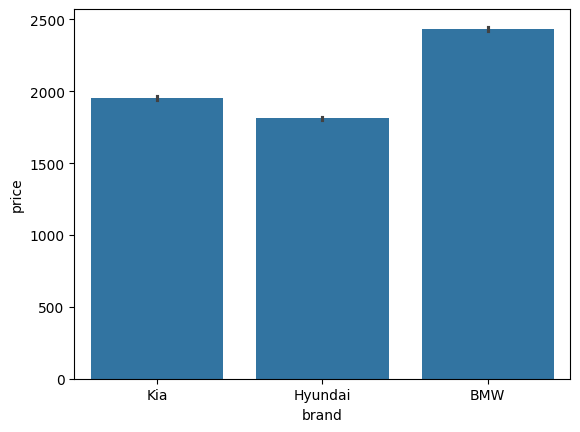

In [6]:
sns.barplot(data=df, x='brand', y='price')

In [ ]:
'BMW'

4.

In [7]:
cond = ((df['brand'] == 'Kia') & (df['accident_yn'] == 1))

filtering_df = df[cond]

repair_cost = filtering_df['repair_cost'].mean()
print(int(repair_cost))

48


5.

In [8]:
# (5-1) 여기에 코드의 오류를 정정하고 실행하세요.
df_temp = df.copy()

print('결측치 처리 전\n', df_temp.isnull().sum())
m_val = df_temp['engine_size'].median()
df_temp['engine_size'] = df_temp['engine_size'].fillna(m_val)
df_temp[['repair_cost', 'option_count']] = df_temp[['repair_cost', 'option_count']].fillna(0)
df_na = df_temp.dropna(subset=['prev_owners'])
print('\n결측치 처리 후\n', df_na.isnull().sum())

결측치 처리 전
 car_id             0
year               0
mileage            0
fuel_type          0
brand              0
engine_size      228
transmission       0
accident_yn        0
option_count     188
prev_owners        0
repair_cost     1045
price              0
dtype: int64

결측치 처리 후
 car_id          0
year            0
mileage         0
fuel_type       0
brand           0
engine_size     0
transmission    0
accident_yn     0
option_count    0
prev_owners     0
repair_cost     0
price           0
dtype: int64


In [ ]:
repair_cost

6.

In [9]:
df_na['car_age'] = 2025 - df_na['year']

df_na = df_na.drop(columns=['year'])

df_na.head(5)

,car_id,mileage,fuel_type,brand,engine_size,transmission,accident_yn,option_count,prev_owners,repair_cost,price,car_age
0,1,107522,Diesel,Kia,1729.0,Manual,0,0.0,1,60.711083,2149,9
1,2,18132,Gasoline,Kia,1581.0,Auto,1,2.0,3,64.514167,2244,3
2,3,53802,Gasoline,Kia,1898.0,Manual,1,1.0,1,50.475857,2020,6
3,4,67485,LPG,Kia,1811.0,Manual,0,1.0,1,73.277078,2144,7
4,5,146270,Gasoline,Hyundai,1733.0,Auto,0,1.0,3,0.000000,1330,12


7.

In [10]:
# (코드 셀) 코드의 빈칸을 채우고 실행하세요.
# 원-핫 인코딩 수행
df_encoded = pd.get_dummies(data=df_na, columns=['fuel_type', 'brand', 'transmission'])

# 타겟(y) 및 피처(X) 분리
y = df_encoded['price']
X = df_encoded.drop(columns=['price', 'car_id'], axis=1)

# 데이터셋 구조 확인
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   mileage              7000 non-null   int64  
 1   engine_size          7000 non-null   float64
 2   accident_yn          7000 non-null   int64  
 3   option_count         7000 non-null   float64
 4   prev_owners          7000 non-null   int64  
 5   repair_cost          7000 non-null   float64
 6   car_age              7000 non-null   int64  
 7   fuel_type_Diesel     7000 non-null   bool   
 8   fuel_type_Gasoline   7000 non-null   bool   
 9   fuel_type_LPG        7000 non-null   bool   
 10  brand_BMW            7000 non-null   bool   
 11  brand_Hyundai        7000 non-null   bool   
 12  brand_Kia            7000 non-null   bool   
 13  transmission_Auto    7000 non-null   bool   
 14  transmission_Manual  7000 non-null   bool   
dtypes: bool(8), float64(3), int64(4)
memor

8.

In [11]:
# (8-1) 여기에 코드의 오류를 정정하고 실행하세요.
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
print(round(X_train_scaled.mean()))

0


9.

In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

lr = LinearRegression()
rf = RandomForestRegressor(random_state=42)
xgb = XGBRegressor(random_state=42)

lr.fit(X_train_scaled, y_train)
rf.fit(X_train_scaled, y_train)
xgb.fit(X_train_scaled, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

10.

In [14]:
# (10-1) 여기에 코드의 오류를 정정하고 실행하세요.
from sklearn.metrics import mean_squared_error

y_pred_lr = lr.predict(X_test_scaled)
y_pred_rf = rf.predict(X_test_scaled)
y_pred_xgb = xgb.predict(X_test_scaled)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

print(rmse_lr, rmse_rf, rmse_xgb)

148.4639654124931 161.728500809521 166.85013859748514


In [ ]:
LinearRegression

11.

In [15]:
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Activation, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.utils import to_categorical
tf.random.set_seed(100)

In [16]:
dl_model = Sequential()
dl_model.add(Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)))
dl_model.add(Dense(32, activation='relu'))
dl_model.add(Dense(1, activation='linear'))

dl_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,137 (12.25 KB)

 Trainable params: 3,137 (12.25 KB)

 Non-trainable params: 0 (0.00 B)

12.

In [18]:
early_stopping = EarlyStopping(monitor='val_loss', patience=5)
model_checkpoint = ModelCheckpoint(filepath='best_model.keras.weights.h5', monitor='val_loss', save_weights_only=True, save_best_only=True)
callbacks = [early_stopping, model_checkpoint]

dl_model.compile(optimizer='adam', loss='mean_squared_error')

history = dl_model.fit(X_train_scaled, y_train, epochs=50, batch_size=32, validation_data=(X_test_scaled, y_test), callbacks=callbacks)

Epoch 1/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 3959957.7500 - val_loss: 3819848.7500
Epoch 2/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 3317128.0000 - val_loss: 2598002.7500
Epoch 3/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1641992.3750 - val_loss: 815078.8125
Epoch 4/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 390447.7188 - val_loss: 167663.6875
Epoch 5/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 105745.9766 - val_loss: 80992.0234
Epoch 6/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 67622.0234 - val_loss: 61281.2344
Epoch 7/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 54007.7109 - val_loss: 51058.5430
Epoch 8/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 46192.5273 - val_loss: 44949.5352
Epoch 9/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 41333.1875 - val_loss: 40974.1328
Epoch 10/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 38080.8867 - val_loss: 38177.4062
Epoch 11/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 4

13.

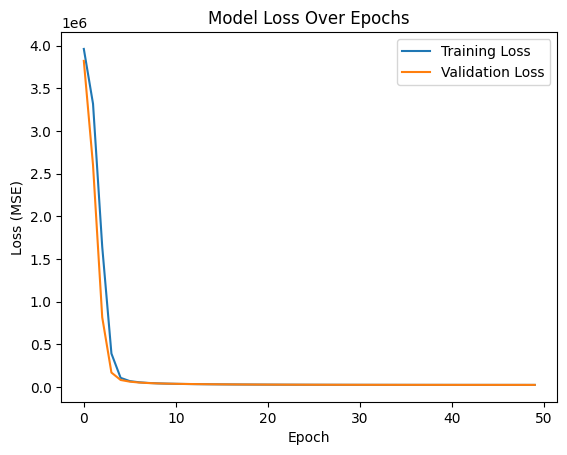

In [19]:
# (코드 셀) 코드의 빈칸을 채우고 실행하세요.
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Model Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.show()

14.

In [20]:
# 새로 입고된 중고차 정보(전처리가 완료된 상태)
import numpy as np
sample_data=np.array([[-0.54, -0.53, 1.53, 2.79, 0.29, 17.8, -1.51, -0.68, 0.85, -0.35, -0.49, -1.01, 1.52, 0.5, -0.5]])

In [21]:
loaded_model = dl_model

loaded_model.load_weights('best_model.keras.weights.h5')

pred = loaded_model.predict(sample_data)

print(f'{pred[0][0]:.2f}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
4300.74


In [22]:
pred_num = pred.item()
print(f'{pred_num:.2f}')

print(round(pred_num, 2))

4300.74
4300.74
